<a href="https://colab.research.google.com/github/gsahithi017-cmd/Data-Science/blob/main/titanic_exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.head())
print(df)

print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

/tmp/ipykernel_2201/813721572.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Pclass", data=df, palette="Set2")


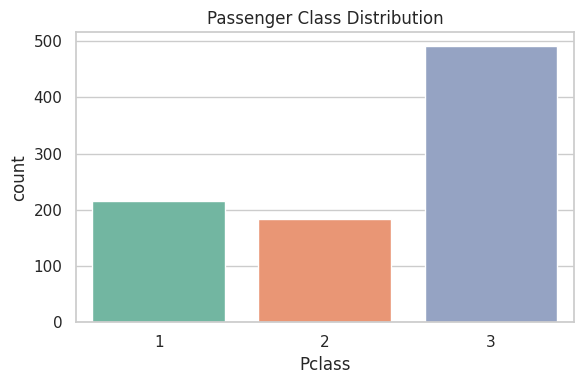

/tmp/ipykernel_2201/813721572.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sex", data=df, palette="Pastel1")


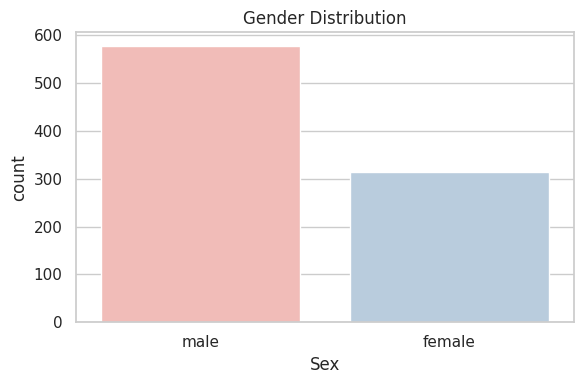

/tmp/ipykernel_2201/813721572.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data=df, palette="Set1")


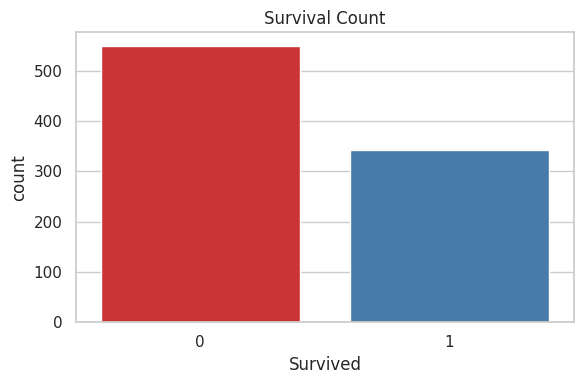

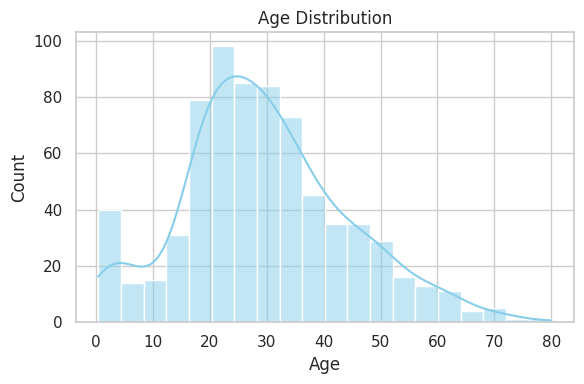

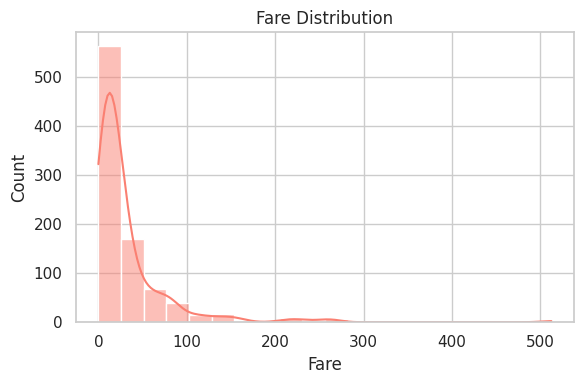

/tmp/ipykernel_2201/813721572.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Fare", data=df, palette="Set3")


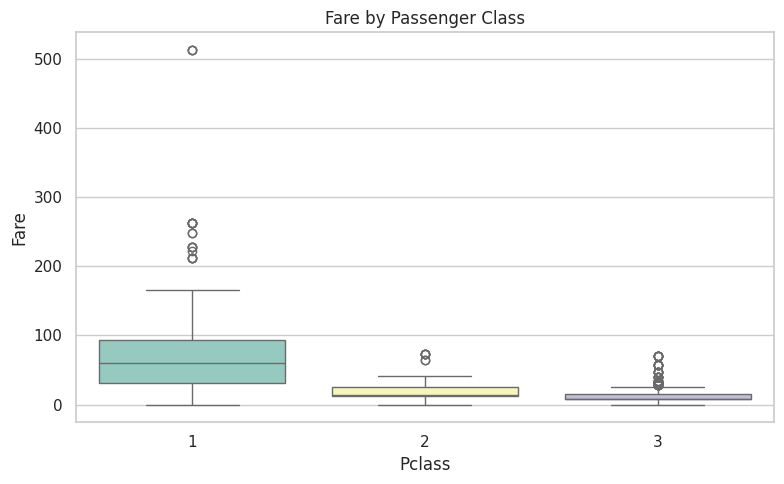

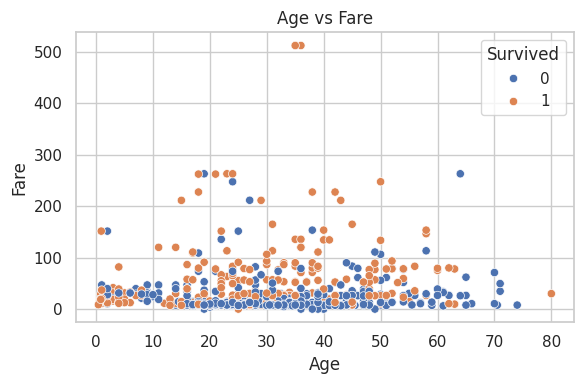

/tmp/ipykernel_2201/813721572.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Embarked", y="Fare", data=df, palette="Set1")


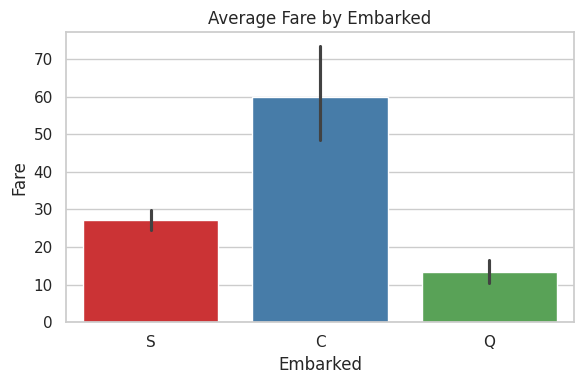

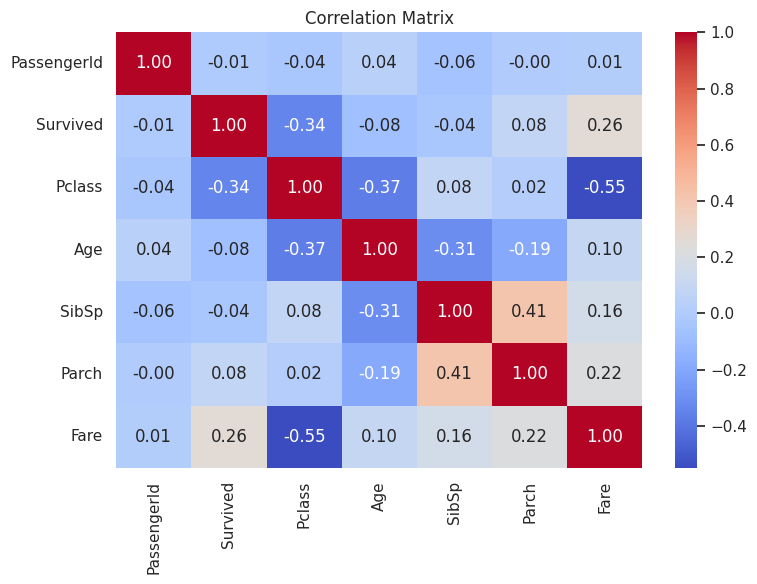

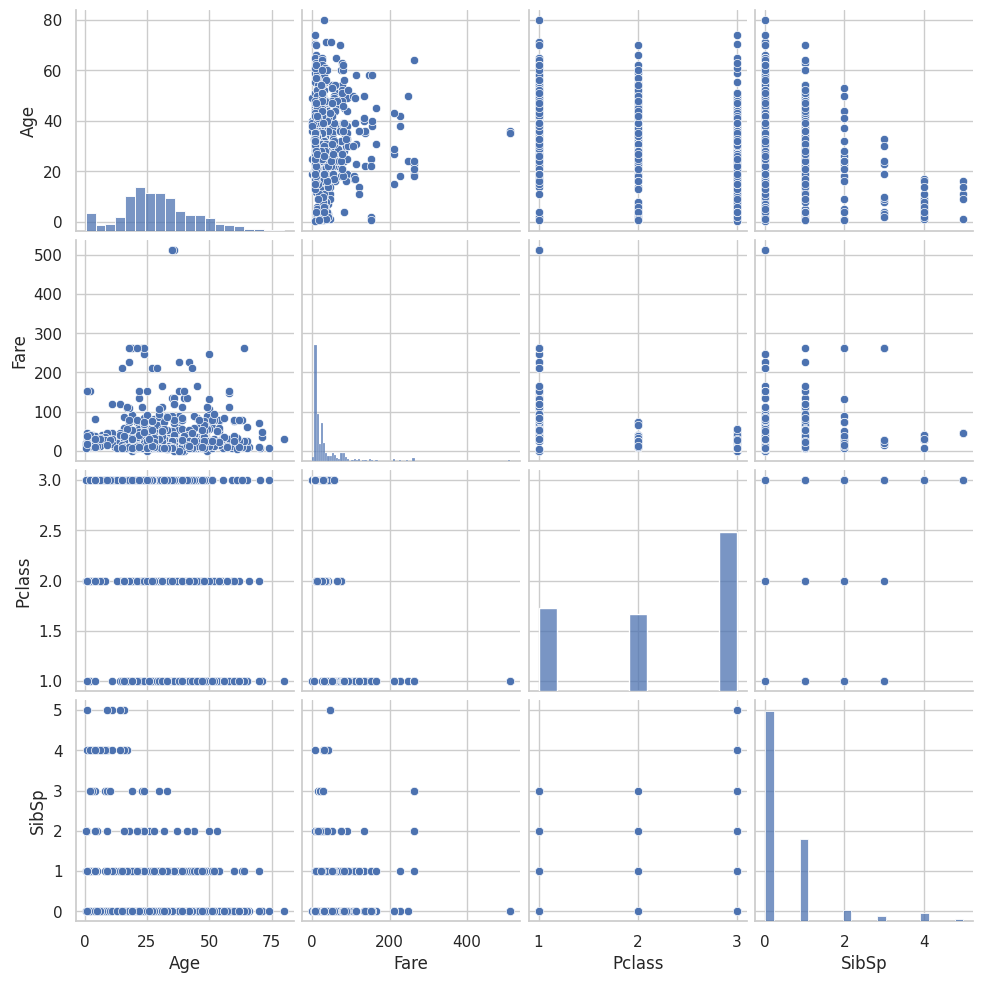

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

sns.set_theme(style="whitegrid")

# 1. Count plot - Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df, palette="Set2")
plt.title("Passenger Class Distribution")
plt.tight_layout()
plt.show()

# 2. Count plot - Sex
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df, palette="Pastel1")
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

# 3. Count plot - Survived
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df, palette="Set1")
plt.title("Survival Count")
plt.tight_layout()
plt.show()

# 4. Histogram - Age
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True, color="skyblue")
plt.title("Age Distribution")
plt.tight_layout()
plt.show()

# 5. Histogram - Fare
plt.figure(figsize=(6,4))
sns.histplot(df["Fare"], bins=20, kde=True, color="salmon")
plt.title("Fare Distribution")
plt.tight_layout()
plt.show()

# 6. Box plot - Fare by Passenger Class
plt.figure(figsize=(8,5))
sns.boxplot(x="Pclass", y="Fare", data=df, palette="Set3")
plt.title("Fare by Passenger Class")
plt.tight_layout()
plt.show()

# 7. Scatter plot - Age vs Fare
plt.figure(figsize=(6,4))
sns.scatterplot(x="Age", y="Fare", data=df, hue="Survived")
plt.title("Age vs Fare")
plt.tight_layout()
plt.show()

# 8. Bar plot - Average Fare by Embarked
plt.figure(figsize=(6,4))
sns.barplot(x="Embarked", y="Fare", data=df, palette="Set1")
plt.title("Average Fare by Embarked")
plt.tight_layout()
plt.show()

# 9. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 10. Pair plot
sns.pairplot(df[["Age","Fare","Pclass","SibSp"]].dropna())
plt.show()

In [7]:
import numpy as np
import pandas as pd

nominal_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Detected nominal attributes:", nominal_cols)
print("Detected numeric attributes:", numeric_cols)


def nominal_dissimilarity_similarity(col1, col2):
    a = df[col1]
    b = df[col2]
    count = 0
    total = 0
    for x, y in zip(a, b):
        if pd.isna(x) or pd.isna(y):
            continue
        total += 1
        if x != y:
            count += 1
    if total == 0:
        return None, None
    dissim = count / total
    sim = 1 - dissim
    return dissim, sim


print("\nNominal Attribute Dissimilarity & Similarity")
for i in range(len(nominal_cols)):
    for j in range(i + 1, len(nominal_cols)):
        col1 = nominal_cols[i]
        col2 = nominal_cols[j]
        dissim, sim = nominal_dissimilarity_similarity(col1, col2)
        if dissim is None:
            print(f"{col1} vs {col2} - No overlapping non-null values")
            continue
        print(f"{col1} vs {col2} - Dissimilarity = {dissim}")
        print(f"{col1} vs {col2} - Similarity   = {sim}")


def numeric_dissimilarity_similarity(col1, col2):
    temp = df[[col1, col2]].dropna()
    if len(temp) < 2:
        return None, None
    v1 = temp.iloc[0][[col1, col2]].values.astype(float)
    v2 = temp.iloc[1][[col1, col2]].values.astype(float)
    distance = np.sqrt(np.sum((v1 - v2) ** 2))
    similarity = 1 / (1 + distance)
    return distance, similarity


print("\nNumeric Attribute Dissimilarity & Similarity")
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]
        distance, sim = numeric_dissimilarity_similarity(col1, col2)
        if distance is None:
            print(f"{col1} vs {col2} - Not enough non-null rows")
            continue
        print(f"{col1} vs {col2} - Euclidean Distance = {distance}")
        print(f"{col1} vs {col2} - Similarity         = {sim}")

Detected nominal attributes: ['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']
Detected numeric attributes: ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

Nominal Attribute Dissimilarity & Similarity
make vs fuel-type - Dissimilarity = 1.0
make vs fuel-type - Similarity   = 0.0
make vs aspiration - Dissimilarity = 1.0
make vs aspiration - Similarity   = 0.0
make vs num-of-doors - Dissimilarity = 1.0
make vs num-of-doors - Similarity   = 0.0
make vs body-style - Dissimilarity = 1.0
make vs body-style - Similarity   = 0.0
make vs drive-wheels - Dissimilarity = 1.0
make vs drive-wheels - Similarity   = 0.0
make vs engine-location - Dissimilarity = 1.0
make vs engine-location - Similarity   = 0.0
make vs engine-type - Dissimilarit